In [1]:
## Libraries needs to run the script ##
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import TPR, XTC
from MDAnalysis.analysis import density 
import numpy as np 
import matplotlib.pyplot as plt 
#import nglview as nv
from MDAnalysis import transformations as trans
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
%matplotlib inline

In [2]:
# Load trajectory
u = mda.Universe("equil8.tpr", ["equil8-pbc.xtc","equil9-pbc.xtc","equil10-pbc.xtc", "equil11-pbc.xtc"], in_memory=True, in_memory_step=50)

# Define atom selections
POLY = u.select_atoms('resname LIG')
EO = u.select_atoms('resname LIG and name EO')
PO = u.select_atoms('resname LIG and name PO')

In [3]:
u.trajectory

<MemoryReader with 1201 frames of 63540 atoms>

In [4]:
## create the density profile for CL ##
##P = u.select_atoms('resname LIG and name C3')
dens = density.DensityAnalysis(EO,
                               delta=4.0,
                               padding=2)
dens.run()

In [5]:
import numpy as np
# ensure that the density is A^{-3}
dens.results.density.convert_density("nm^{-3}")
dens.results.density.convert_length("nm")

In [6]:
dens.results.density.units

{'length': 'nm', 'density': 'nm^{-3}'}

In [7]:
grid = dens.results.density.grid
grid.shape

(49, 49, 51)

In [8]:
mx, my, mz = dens.results.density.midpoints

In [9]:
grid = dens.results.density.grid
flat = grid.ravel() / (grid.max()*10)

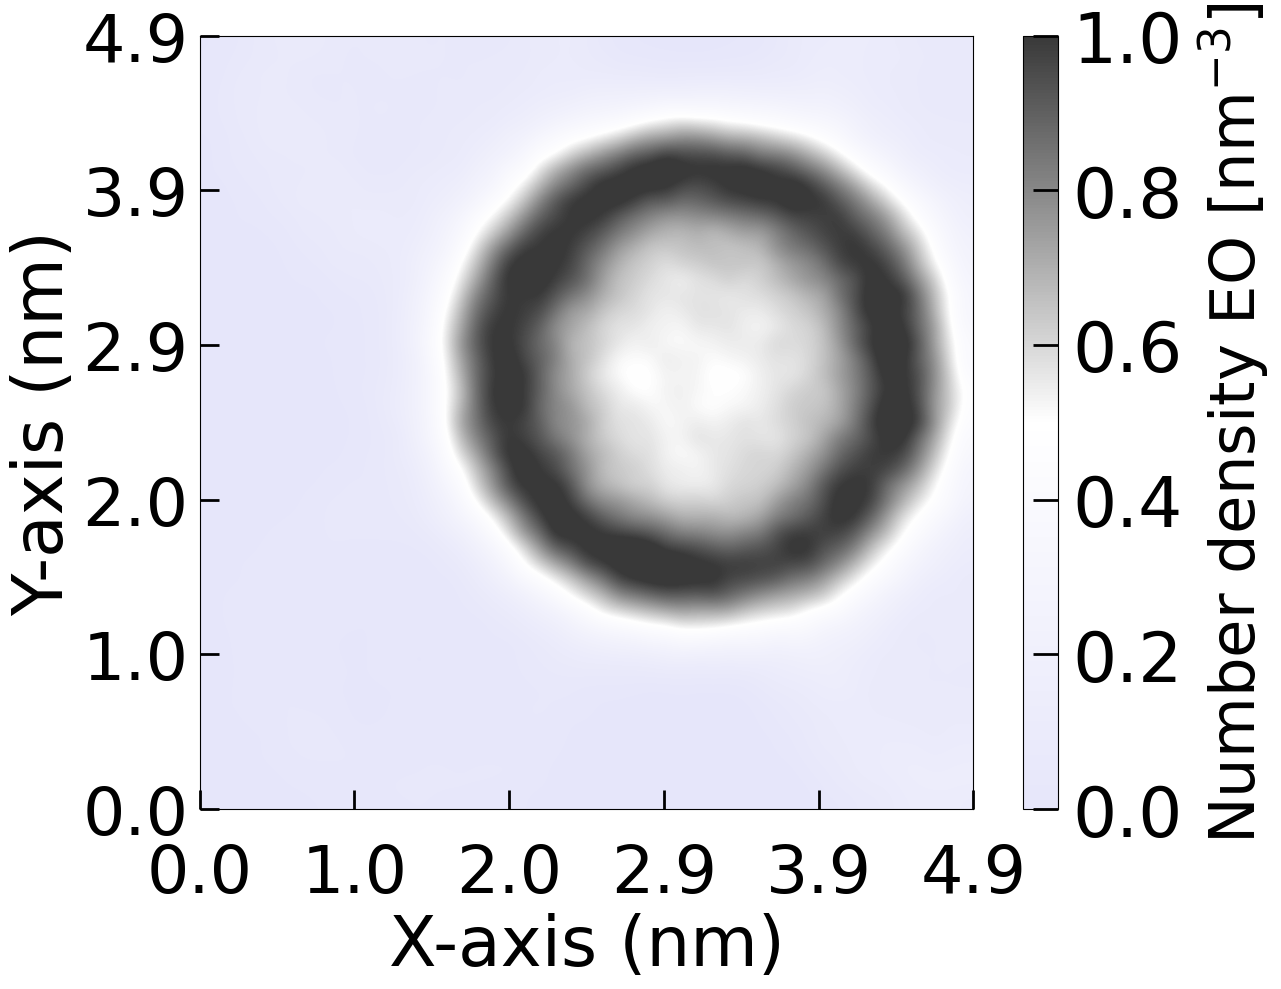

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap: blue → white → magenta
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_bwmag', ['lavender', 'white', '#393939']
)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

avg = grid.mean(axis=-1)

# Get shape of data for pixel index ranges
ny, nx = avg.shape

# Compute physical extent in nanometers (assuming 1 Å = 0.1 nm)
x_extent_nm = nx * 0.1
y_extent_nm = ny * 0.1

# Main plot with proper origin and extent
im = ax.imshow(
    avg, interpolation='bicubic', alpha=1, vmax=1, vmin=0, cmap=custom_cmap,
    origin='lower', extent=[0, x_extent_nm, 0, y_extent_nm]
)
# Keep axes square (1:1 data units)
ax.set_aspect('equal', adjustable='box')

# Remove extra space around axes by shrinking the colorbar instead of main plot
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4.5%", pad=0.50)
##avg.shape
##im = ax.imshow(avg, interpolation='bicubic', alpha=1, vmax=1, vmin=0, cmap=custom_cmap)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Number density EO [nm$^{-3}$]', fontsize=45, fontname='DejaVu Sans', labelpad=10)
cbar.ax.tick_params(labelsize=50, direction='in', length=18, width=2, pad=10)

# Tick positions in nm
x_ticks = np.linspace(0, x_extent_nm, 6)
y_ticks = np.linspace(0, y_extent_nm, 6)

x_labels = [f"{x:.1f}" for x in x_ticks]
y_labels = [f"{y:.1f}" for y in y_ticks]

##plt.xlabel('X-axis (Å)', fontsize=40, fontname='DejaVu Sans')
##plt.ylabel('Y-axis (Å)', fontsize=40, fontname='DejaVu Sans')
##plt.ylim(0, 49)
##plt.xlim(0, 50)
##plt.xticks(np.arange(0, 50.001, 10), fontsize=40, fontname='DejaVu Sans')
##plt.yticks(np.arange(0, 49.001, 10), fontsize=40, fontname='DejaVu Sans')
##plt.tick_params(axis='both', which='major', labelsize=40, direction='in', length=18, width=2, pad=10)
ax.set_xlabel('X-axis (nm)', fontsize=50, fontname='DejaVu Sans')
ax.set_ylabel('Y-axis (nm)', fontsize=50, fontname='DejaVu Sans')
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticklabels(x_labels, fontsize=48, fontname='DejaVu Sans')
ax.set_yticklabels(y_labels, fontsize=48, fontname='DejaVu Sans')

ax.tick_params(axis='x', which='major', direction='in', length=14, width=2, pad=24)
ax.tick_params(axis='y', which='major', direction='in', length=14, width=2, pad=8)

# Manual layout adjustment
fig.subplots_adjust(left=0.12, right=0.88, bottom=0.12, top=0.95)

##save and show##
plt.tight_layout()
plt.show()
fig.savefig('Figure4-EO-xy-nm.jpg', bbox_inches='tight', dpi=500)

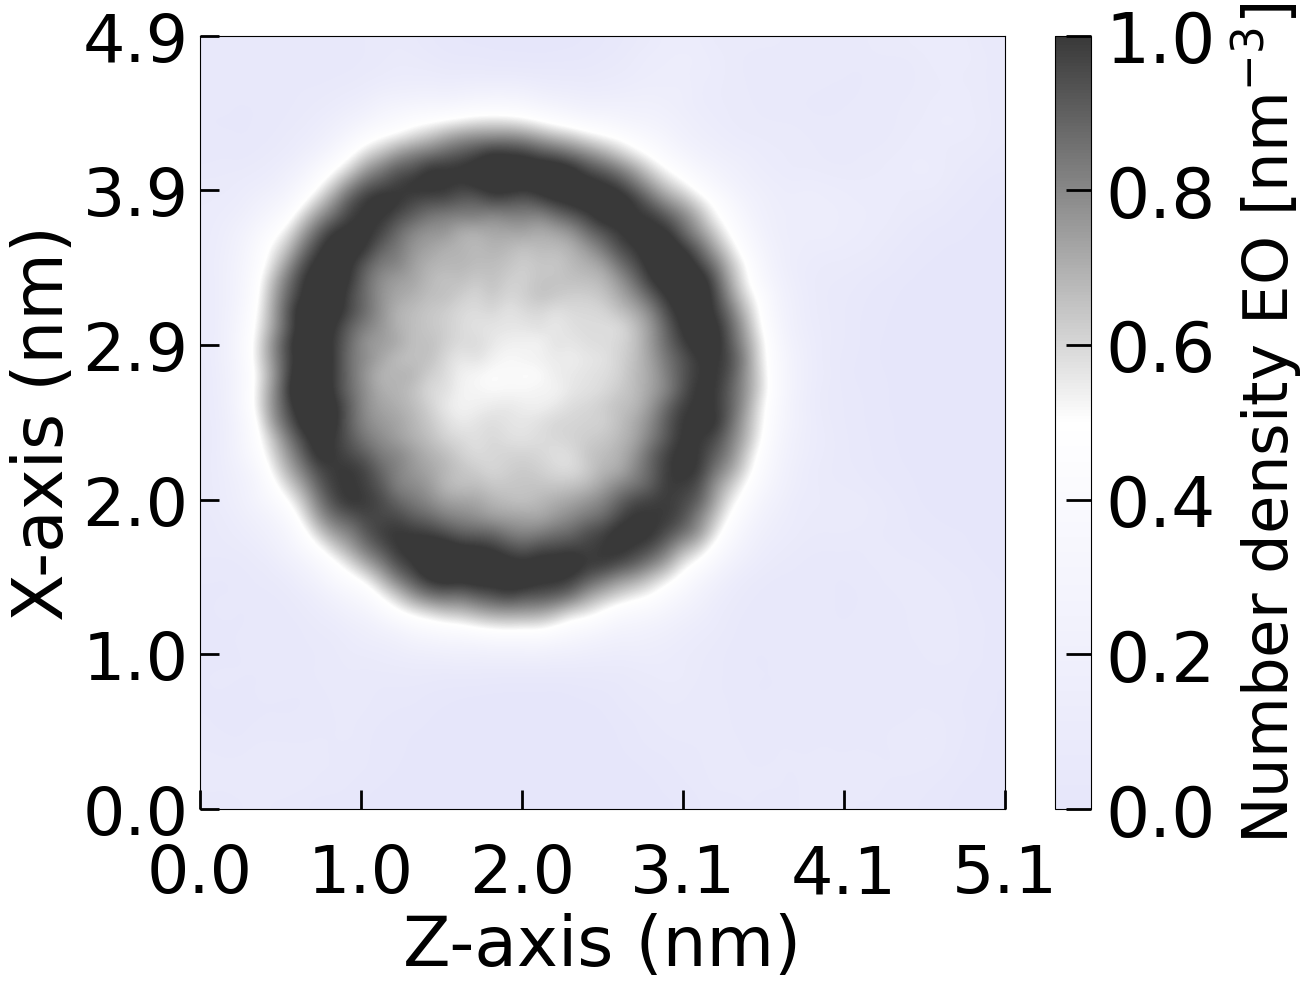

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap: blue → white → magenta
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_bwmag', ['lavender', 'white', '#393939']
)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

avg = grid.mean(axis=1)

# Get shape of data for pixel index ranges
ny, nx = avg.shape

# Compute physical extent in nanometers (assuming 1 Å = 0.1 nm)
x_extent_nm = nx * 0.1
y_extent_nm = ny * 0.1

# Main plot with proper origin and extent
im = ax.imshow(
    avg, interpolation='bicubic', alpha=1, vmax=1, vmin=0, cmap=custom_cmap,
    origin='lower', extent=[0, x_extent_nm, 0, y_extent_nm]
)
##avg.shape
##im = ax.imshow(avg, interpolation='bicubic', alpha=1, vmax=1, vmin=0, cmap=custom_cmap)
# Keep axes square (1:1 data units)
ax.set_aspect('equal', adjustable='box')

# Remove extra space around axes by shrinking the colorbar instead of main plot
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4.5%", pad=0.50)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Number density EO [nm$^{-3}$]', fontsize=45, fontname='DejaVu Sans', labelpad=10)
cbar.ax.tick_params(labelsize=50, direction='in', length=18, width=2, pad=10)

# Tick positions in nm
x_ticks = np.linspace(0, x_extent_nm, 6)
y_ticks = np.linspace(0, y_extent_nm, 6)

x_labels = [f"{x:.1f}" for x in x_ticks]
y_labels = [f"{y:.1f}" for y in y_ticks]

##plt.xlabel('Z-axis (Å)', fontsize=40, fontname='DejaVu Sans')
##plt.ylabel('X-axis (Å)', fontsize=40, fontname='DejaVu Sans')
##plt.ylim(0, 49)
##plt.xlim(0, 50)
##plt.xticks(np.arange(0, 50.001, 10), fontsize=40, fontname='DejaVu Sans')
##plt.yticks(np.arange(0, 49.001, 10), fontsize=40, fontname='DejaVu Sans')
##plt.tick_params(axis='both', which='major', labelsize=40, direction='in', length=18, width=2, pad=10)
ax.set_xlabel('Z-axis (nm)', fontsize=50, fontname='DejaVu Sans')
ax.set_ylabel('X-axis (nm)', fontsize=50, fontname='DejaVu Sans')
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticklabels(x_labels, fontsize=48, fontname='DejaVu Sans')
ax.set_yticklabels(y_labels, fontsize=48, fontname='DejaVu Sans')

ax.tick_params(axis='x', which='major', direction='in', length=14, width=2, pad=24)
ax.tick_params(axis='y', which='major', direction='in', length=14, width=2, pad=8)

# Manual layout adjustment
fig.subplots_adjust(left=0.12, right=0.88, bottom=0.12, top=0.95)
##Save and show 
plt.tight_layout()
plt.show()
fig.savefig('Figure4-EO-xz-nm.jpg', bbox_inches='tight', dpi=500)